In [ ]:
# ==============================
# PHASE 1: TRADITIONAL ML PIPELINE
# Airbus Ship Detection
# ==============================

# --- IMPORTS ---
import os
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
from skimage.feature import graycomatrix, graycoprops
from skimage.color import rgb2gray
from skimage import io
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# ==============================
# STEP 1: LOAD DATASET METADATA
# ==============================
BASE_PATH = "/kaggle/input/airbus-ship-detection"
TRAIN_CSV = os.path.join(BASE_PATH, "train_ship_segmentations_v2.csv")
TRAIN_IMG_DIR = os.path.join(BASE_PATH, "train_v2")

df = pd.read_csv(TRAIN_CSV)
df['has_ship'] = df['EncodedPixels'].notnull().astype(int)
df = df.groupby('ImageId').agg({'has_ship':'max'}).reset_index()

print(f"Total images: {len(df)}, Ships: {df['has_ship'].sum()}, No Ships: {len(df)-df['has_ship'].sum()}")

# ==============================
# STEP 2: TRAIN / TEST SPLIT (seed=9)
# ==============================
df_subset = df.sample(n=15000, random_state=9)
train_df = df_subset.sample(n=7000, random_state=9)
remaining = df_subset.drop(train_df.index)
test_df = remaining.sample(n=5000, random_state=9)

y_train = train_df['has_ship'].values
y_test = test_df['has_ship'].values
print(f"Train: {len(train_df)}, Test: {len(test_df)}")

# ==============================
# STEP 3: SAFE IMAGE LOADING
# ==============================
IMG_SIZE = 256   # ✅ Resize 256×256

def safe_load_image(img_path, img_size=IMG_SIZE):
    try:
        img = io.imread(img_path)
        if img is None:
            return None
        img = cv2.resize(img, (img_size, img_size))
        if img.ndim == 2:  # grayscale -> RGB
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif img.shape[2] > 3:
            img = img[:, :, :3]
        return img
    except Exception:
        return None

def load_images_with_retry(df, img_dir, img_size=IMG_SIZE):
    X_images = []
    y_labels = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        img_path = os.path.join(img_dir, row['ImageId'])
        img = safe_load_image(img_path, img_size)
        if img is not None:
            X_images.append(img)
            y_labels.append(row['has_ship'])
    return np.array(X_images), np.array(y_labels)

print("Loading training images...")
X_train, y_train = load_images_with_retry(train_df, TRAIN_IMG_DIR)
print("Loading testing images...")
X_test, y_test = load_images_with_retry(test_df, TRAIN_IMG_DIR)

print(f"Successfully loaded: Train={len(X_train)}, Test={len(X_test)}")

Total images: 192556, Ships: 42556, No Ships: 150000
Train: 7000, Test: 5000
Loading training images...


100%|██████████| 7000/7000 [02:27<00:00, 47.62it/s]


Loading testing images...


100%|██████████| 5000/5000 [01:35<00:00, 52.31it/s]


Successfully loaded: Train=6999, Test=5000


In [4]:
# ==============================
# STEP 4: FEATURE EXTRACTION FUNCTIONS
# ==============================
def extract_hu_moments(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    moments = cv2.moments(gray)
    hu = cv2.HuMoments(moments).flatten()
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-7)
    return hu

def extract_haralick_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    glcm = graycomatrix(gray, distances=[1],
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        symmetric=True, normed=True)
    props = []
    for prop in ['contrast', 'dissimilarity', 'homogeneity', 'ASM', 'energy', 'correlation']:
        vals = graycoprops(glcm, prop)
        props.append(vals.mean())
    return np.array(props)

def extract_color_histogram(img, bins=(8,8,8)):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    hist = cv2.calcHist([hsv], [0,1,2], None, bins, [0,180,0,256,0,256])
    hist = cv2.normalize(hist, hist).flatten()
    return hist

# ==============================
# STEP 5: BUILD FEATURE SETS
# ==============================
print("Extracting features for training set...")
train_hu = np.array([extract_hu_moments(img) for img in tqdm(X_train)])
train_ha = np.array([extract_haralick_features(img) for img in tqdm(X_train)])
train_his = np.array([extract_color_histogram(img) for img in tqdm(X_train)])

print("Extracting features for testing set...")
test_hu = np.array([extract_hu_moments(img) for img in tqdm(X_test)])
test_ha = np.array([extract_haralick_features(img) for img in tqdm(X_test)])
test_his = np.array([extract_color_histogram(img) for img in tqdm(X_test)])


Extracting features for training set...


100%|██████████| 6999/6999 [00:03<00:00, 2011.18it/s]


Extracting features for testing set...


100%|██████████| 5000/5000 [00:02<00:00, 2043.42it/s]


In [58]:
# ==============================
# STEP 6: MODEL EVALUATION FUNCTION
# ==============================
def evaluate_models(X_train, X_test, y_train, y_test, label_suffix):
    print(f"\n➡ Evaluating models for feature set: {label_suffix} ...")
    
    # ✅ Use MinMaxScaler instead of StandardScaler
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    models = {
        "LDA": LinearDiscriminantAnalysis(),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "Naive Bayes": GaussianNB(),
        "Random Forest": RandomForestClassifier(
            n_estimators=140, max_depth=30, min_samples_leaf=1,
            max_features='sqrt', random_state=9
        ),
        "SVM": SVC(kernel='rbf', C=1.0, gamma='scale', random_state=9)
    }

    results = {}
    for name, model in models.items():
        print(f"   Training {name} ...", end="")
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, preds)
        results[f"{name} | {label_suffix}"] = acc
        print(f" Done! Accuracy: {acc*100:.2f}%")
    print(f"✅ Completed feature set: {label_suffix}")
    return results


In [59]:
# ==============================
# STEP 7: TRAINING ALL COMBINATIONS
# ==============================
results = {}
results.update(evaluate_models(train_his, test_his, y_train, y_test, "His"))
results.update(evaluate_models(train_ha, test_ha, y_train, y_test, "Ha"))
results.update(evaluate_models(train_hu, test_hu, y_train, y_test, "Hu"))
results.update(evaluate_models(np.hstack((train_hu, train_ha)),
                               np.hstack((test_hu, test_ha)), y_train, y_test, "Hu+Ha"))
results.update(evaluate_models(np.hstack((train_ha, train_his)),
                               np.hstack((test_ha, test_his)), y_train, y_test, "Ha+His"))
results.update(evaluate_models(np.hstack((train_hu, train_his)),
                               np.hstack((test_hu, test_his)), y_train, y_test, "Hu+His"))
results.update(evaluate_models(np.hstack((train_hu, train_ha, train_his)),
                               np.hstack((test_hu, test_ha, test_his)), y_train, y_test, "All"))


➡ Evaluating models for feature set: His ...
   Training LDA ... Done! Accuracy: 78.38%
   Training KNN ... Done! Accuracy: 79.86%
   Training Naive Bayes ... Done! Accuracy: 78.32%
   Training Random Forest ... Done! Accuracy: 92.04%
   Training SVM ... Done! Accuracy: 79.30%
✅ Completed feature set: His

➡ Evaluating models for feature set: Ha ...
   Training LDA ... Done! Accuracy: 77.36%
   Training KNN ... Done! Accuracy: 77.70%
   Training Naive Bayes ... Done! Accuracy: 77.36%
   Training Random Forest ... Done! Accuracy: 82.64%
   Training SVM ... Done! Accuracy: 77.80%
✅ Completed feature set: Ha

➡ Evaluating models for feature set: Hu ...
   Training LDA ... Done! Accuracy: 77.42%
   Training KNN ... Done! Accuracy: 73.86%
   Training Naive Bayes ... Done! Accuracy: 77.36%
   Training Random Forest ... Done! Accuracy: 76.60%
   Training SVM ... Done! Accuracy: 77.42%
✅ Completed feature set: Hu

➡ Evaluating models for feature set: Hu+Ha ...
   Training LDA ... Done! Accura


✅ Final Accuracies:
LDA | His: 78.38%
LDA | Ha: 77.36%
LDA | Hu: 77.42%
LDA | Hu+Ha: 77.14%
LDA | Ha+His: 80.14%
LDA | Hu+His: 78.42%
LDA | All: 80.52%
KNN | His: 79.86%
KNN | Ha: 77.70%
KNN | Hu: 73.86%
KNN | Hu+Ha: 77.64%
KNN | Ha+His: 82.76%
KNN | Hu+His: 78.18%
KNN | All: 78.70%
Naive Bayes | His: 78.32%
Naive Bayes | Ha: 77.36%
Naive Bayes | Hu: 77.36%
Naive Bayes | Hu+Ha: 76.76%
Naive Bayes | Ha+His: 78.38%
Naive Bayes | Hu+His: 78.30%
Naive Bayes | All: 78.28%
Random Forest | His: 92.04%
Random Forest | Ha: 82.64%
Random Forest | Hu: 76.60%
Random Forest | Hu+Ha: 83.94%
Random Forest | Ha+His: 92.10%
Random Forest | Hu+His: 92.00%
Random Forest | All: 92.48%
SVM | His: 79.30%
SVM | Ha: 77.80%
SVM | Hu: 77.42%
SVM | Hu+Ha: 77.42%
SVM | Ha+His: 80.62%
SVM | Hu+His: 78.20%
SVM | All: 78.60%


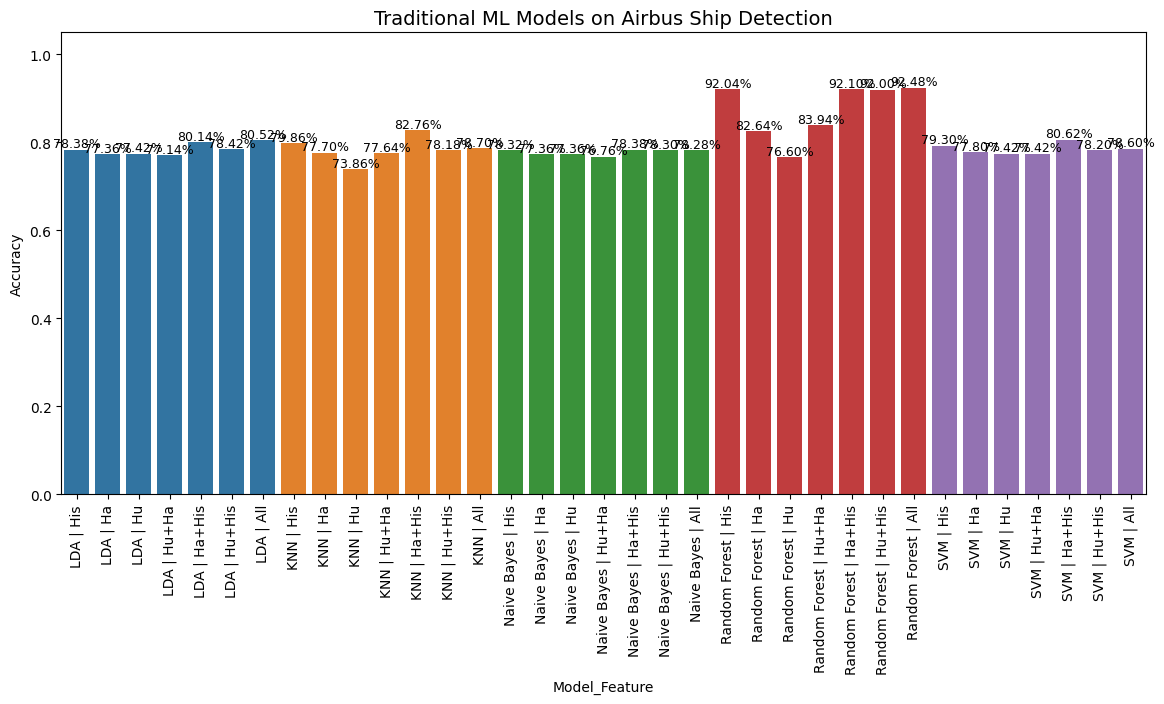

In [60]:
# ==============================
# STEP 8: VISUALIZE RESULTS
# ==============================
model_order = ["LDA", "KNN", "Naive Bayes", "Random Forest", "SVM"]
feature_order = ["His", "Ha", "Hu", "Hu+Ha", "Ha+His", "Hu+His", "All"]

data_list = []
print("\n✅ Final Accuracies:")
for model in model_order:
    for feat in feature_order:
        key = f"{model} | {feat}"
        if key in results:
            acc_percent = results[key]*100
            data_list.append({"Model_Feature": key, "Accuracy": results[key]})
            print(f"{key}: {acc_percent:.2f}%")

results_df = pd.DataFrame(data_list)
palette = sns.color_palette("tab10", len(model_order))
model_colors = {model: palette[i] for i, model in enumerate(model_order)}
bar_colors = [model_colors[res.split(" | ")[0]] for res in results_df["Model_Feature"]]

plt.figure(figsize=(14,6))
sns.barplot(x='Model_Feature', y='Accuracy', data=results_df, palette=bar_colors)
plt.xticks(rotation=90)
for i, row in enumerate(results_df.itertuples()):
    plt.text(i, row.Accuracy + 0.005, f"{row.Accuracy*100:.2f}%", ha='center', fontsize=9)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Traditional ML Models on Airbus Ship Detection", fontsize=14)
plt.show()